# Aufgabe 2

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

x = torch.linspace(-10, 10, 1001).unsqueeze(1) #1001 columns 1 row=feature
y = torch.sin(15 / (torch.abs(x) + 0.5)) - 3 * torch.cos(-x) + 0.7 * x

class MLP(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()
        self.hidden = nn.Linear(n_inputs, 20) #bias neuron automatically handled
        self.output = nn.Linear(20, 1)
        nn.init.uniform_(self.hidden.weight, -1, 1) #weights
        nn.init.uniform_(self.hidden.bias, -1, 1) #bias weight
        nn.init.uniform_(self.output.weight, -1, 1)
        nn.init.uniform_(self.output.bias, -1, 1)      

    def forward(self,x):
        x = self.hidden(x)
        x = torch.sigmoid(x)
        x = self.output(x)
        return x    

In [40]:
model = MLP(n_inputs=1)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.output.parameters(), 0.005) #nur output layer

loss_history = []

#training
for epoch in range(5000):
    y_pred = model(x)
    loss = loss_fn(y_pred,y)
    loss_history.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

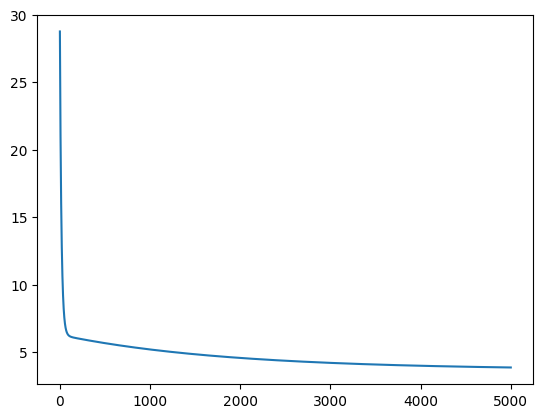

In [41]:
#fehlerfkt plot
x_axis = np.linspace(0, 5000, 5000)
plt.plot(x_axis, loss_history)
plt.show()

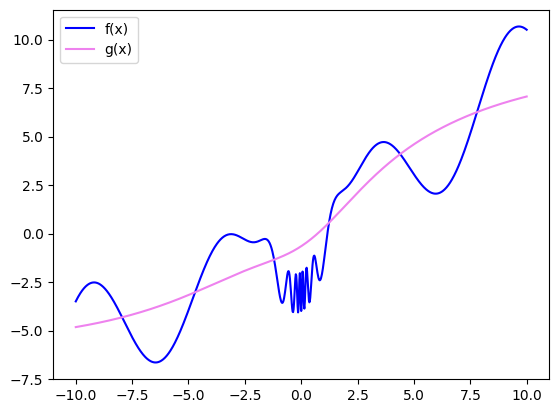

In [42]:
#funktionen plot

with torch.no_grad():
    y_pred = model(x) #get pred

#turn into numpy arrays
x_np = x.squeeze().numpy()
y_np = y.squeeze().numpy()
y_pred_np = y_pred.squeeze().numpy()

plt.plot(x_np, y_np, color = "blue", label = "f(x)")
plt.plot(x_np, y_pred_np, color = "violet", label = "g(x)")

plt.legend()
plt.show()

# Aufgabe 3

In [43]:
model = MLP(n_inputs=1)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), 0.005) #alle parameter

loss_history = []

#training
for epoch in range(5000):
    y_pred = model(x)
    loss = loss_fn(y_pred,y)
    loss_history.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

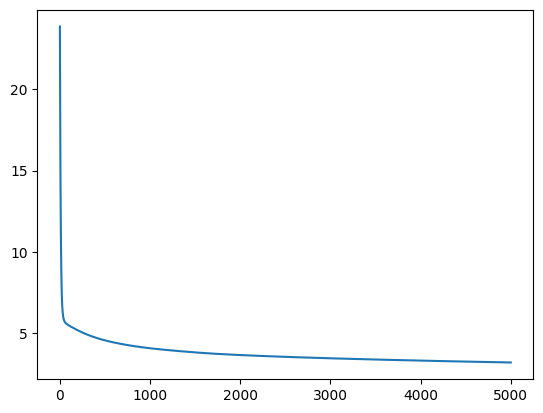

In [44]:
#fehlerfkt plot
x_axis = np.linspace(0, 5000, 5000)
plt.plot(x_axis, loss_history)
plt.show()

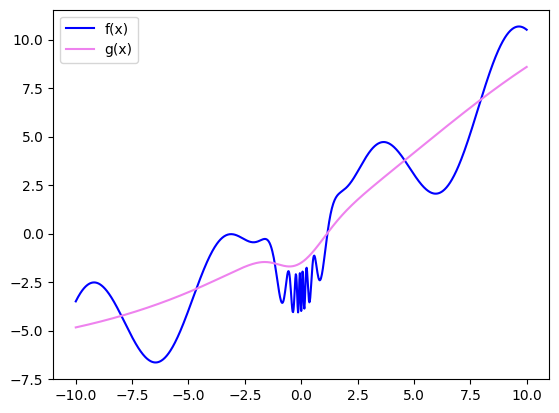

In [45]:
#funktionen plot

with torch.no_grad():
    y_pred_all = model(x) #get pred

#turn into numpy arrays
y_pred_all_np = y_pred_all.squeeze().numpy()

plt.plot(x_np, y_np, color = "blue", label = "f(x)")
plt.plot(x_np, y_pred_all_np, color = "violet", label = "g(x)")

plt.legend()
plt.show()

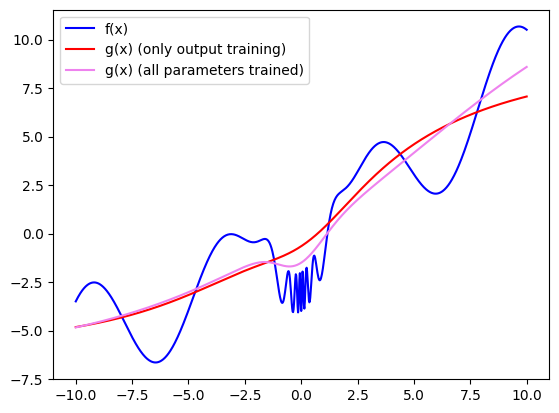

In [46]:
#Only Output VS All Parameters
plt.plot(x_np, y_np, color = "blue", label = "f(x)")
plt.plot(x_np, y_pred_np, color = "red", label = "g(x) (only output training)")
plt.plot(x_np, y_pred_all_np, color = "violet", label = "g(x) (all parameters trained)")


plt.legend()
plt.show()

**Commentar:** Gradient Vanishing Problem?